In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

In [3]:
def load_from_tensorboard(experiment_dir, tag):
    event_files = sorted(experiment_dir.glob("events.out.tfevents.*"), key=lambda p: p.stat().st_mtime)

    latest_event_file = event_files[-1]
    ea = event_accumulator.EventAccumulator(str(latest_event_file))
    ea.Reload()

    if tag not in ea.Tags()["scalars"]:
        return None, None, None
    scalar_events = ea.Scalars(tag)
    steps = [e.step for e in scalar_events]
    values = [e.value for e in scalar_events]
    wall_times = [e.wall_time for e in scalar_events]
    wall_times = [wt - wall_times[0] for wt in wall_times]
    return steps, values, wall_times

def get_wall_time_at_episode(episodes, wall_times, target_episode):
    for ep, wt in zip(episodes, wall_times):
        if ep >= target_episode:
            return round(wt, 2)
    return None

def ax_reinforce(ax, folder_name, metric, train_name, metric_sec=None, converged_metric=None, wall_time=False):
    folder_path = Path(f"../runs/{folder_name}")
    experiments = sorted([p for p in folder_path.iterdir() if p.is_dir()], key=lambda p: p.name.lower())

    for exp_dir in experiments:
        episodes_main, values_main, wall_times_main = load_from_tensorboard(exp_dir, metric)
    
        if wall_time:
            ax.plot(wall_times_main, values_main, label=train_name, linewidth=1.8, color="green")
        else:
            ax.plot(episodes_main, values_main, label=train_name, linewidth=1.8, color="green")

        if metric_sec is not None:
            episodes_sec, values_sec, wall_times_sec = load_from_tensorboard(exp_dir, metric_sec)
            if episodes_sec is not None:
                if wall_time:
                    ax.plot(wall_times_sec, values_sec, linewidth=1.0, alpha=0.5, label=f"{metric_sec.split('/')[0]} per wall time", color="green")
                else:
                    ax.plot(episodes_sec, values_sec, linewidth=1.0, alpha=0.5, label=f"{metric_sec.split('/')[0]} per episode", color="green")

    if converged_metric is not None:
        if wall_time:
            
            wall_converged_metric = get_wall_time_at_episode(episodes_main, wall_times_main, converged_metric)

            ax.axvline(x=wall_converged_metric, color='green', linestyle='--', label=f'Converged in {wall_converged_metric} (s)')
        else:
            ax.axvline(x=converged_metric, color='green', linestyle='--', label=f'Converged in {converged_metric} episodes')

    return ax

def ax_dqn(ax, metric, train_name, converged_in, wall_time=False):
    experiment = Path("../runs/dqn/cartpole/epi_199_buf_10000_steps_500_g_0.99_lr_0.001_target_130_eps_0.01_max_eps_1.0_decay_0.02_batch_64")
    # experiment = Path("../runs/dqn/cartpole/epi_199_buf_10000_steps_500_g_0.99_lr_0.001_target_130_eps_0.01_max_eps_1.0_decay_0.02_batch_64_b")
    # experiment = Path("../runs/dqn/cartpole/epi_200_buf_10000_steps_500_g_0.99_lr_0.0005_target_70_eps_0.01_max_eps_1.0_decay_0.02_batch_64")

    episodes, values, wall_times = load_from_tensorboard(experiment, metric)

    if wall_time:
        ax.plot(wall_times, values, label=train_name, linewidth=1.8, color="red")
        wall_converged_metric = get_wall_time_at_episode(episodes, wall_times, converged_in)
        ax.axvline(x=wall_converged_metric, color='red', linestyle='--', label=f'Converged in {wall_converged_metric} (s)')
    else:
        ax.plot(episodes, values, label=train_name, linewidth=1.8, color="red")
        ax.axvline(x=converged_in, color='red', linestyle='--', label=f'Converged in {converged_in} episodes')

    return ax

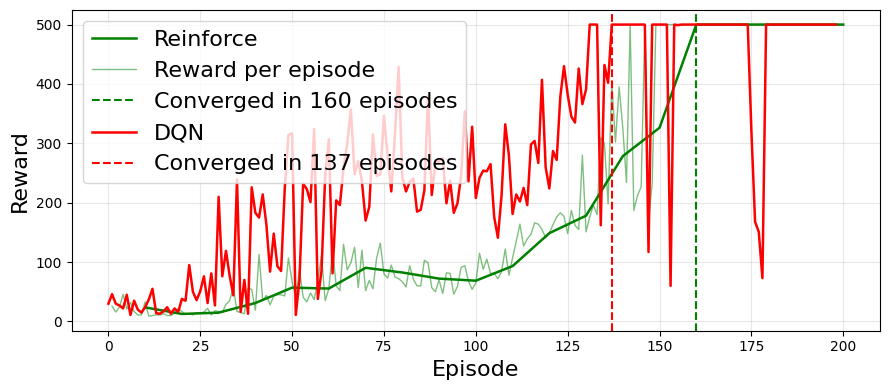

In [ ]:
folder_name = "reinforce"
train_name = "Reinforce"
baseline_name = "Reinforce Baseline"

fig, ax = plt.subplots(figsize=(9, 4))
ax = ax_reinforce(ax, folder_name, "Mean Reward/Episode", train_name, "Reward/Episode", 160, wall_time=False)
ax = ax_dqn(ax, "Reward/Episode", "DQN", converged_in=137, wall_time=False)
ax.set_xlabel("Episode", fontsize=16)
ax.set_ylabel("Reward", fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=16)
fig.tight_layout()

image_name = "reward_episode_r_vs_dqn"
path = Path(f"../images/{image_name}.png")
if not path.parent.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(path, dpi=300)
plt.show()

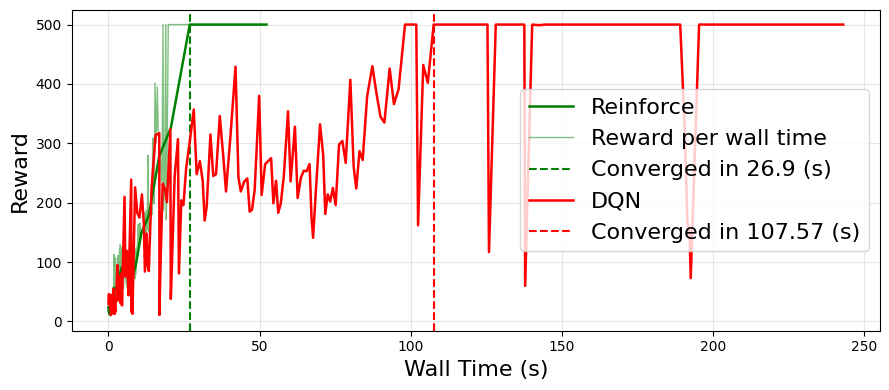

In [5]:
folder_name = "reinforce"

train_name = "Reinforce"
baseline_name = "Reinforce Baseline"
image_name = "reward_per_episode_comparison"

fig, ax = plt.subplots(figsize=(9, 4))
ax = ax_reinforce(ax, folder_name, "Mean Reward/Episode", train_name, "Reward/Episode", 160, wall_time=True)
ax = ax_dqn(ax, "Reward/Episode", "DQN", converged_in=137, wall_time=True)

ax.set_xlabel("Wall Time (s)", fontsize=16)
ax.set_ylabel("Reward", fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=16)
fig.tight_layout()

image_name = "reward_wall_time_r_vs_dqn"
path = Path(f"../images/{image_name}.png")
if not path.parent.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(path, dpi=300)
plt.show()